In [1]:
import os
import json
from matplotlib import pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn
import itertools

from dotenv import load_dotenv
load_dotenv()

DATASET_ROOT = os.environ["DATASET_ROOT"]


In [2]:
model_dir = "../../models"
all_major_runs = [
    "UTAE_hedge_1.1_far",
    "UTAE_hedge_1.1_near",
    "UTAE_hedge_1.2_train_subtropic_test_temperate",
    "UTAE_hedge_1.2_train_temperate_test_subtropic"
]
near_far_runs = [
    "UTAE_hedge_1.1_far",
    "UTAE_hedge_1.1_near",
]

different_thz_class_runs = [
    "UTAE_hedge_1.2_train_subtropic_test_temperate",
    "UTAE_hedge_1.2_train_temperate_test_subtropic",
    "UTAE_hedge_1.2"
    
]

verify_train_sub_test_temp_runs = [
    "UTAE_hedge_1.2_train_subtropic_test_temperate",
    "UTAE_hedge_1.2_downsample_to_train_subtropic_test_temperate"
]

verify_train_temp_test_sub_runs = [
    "UTAE_hedge_1.2_train_temperate_test_subtropic",
    "UTAE_hedge_1.2_downsample_to_train_temperate_test_subtropic"
]



In [3]:
gdf = gpd.read_file(f"{DATASET_ROOT}/metadata.geojson")
list(pd.Series(gdf["thz_class"]).unique())

['TRC5: Subtropics, cool',
 'TRC7: Temperate, cool',
 'TRC4: Subtropics, moderately cool',
 'TRC8: Boreal / Cold, no permafrost',
 'TRC6: Temperate, moderately cool']

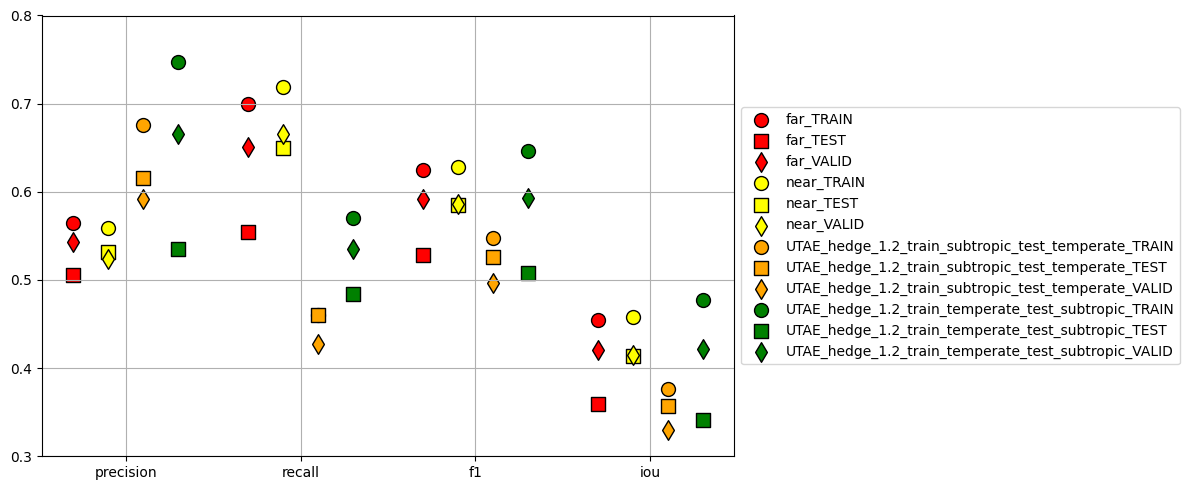

In [4]:
from itertools import cycle
import itertools


def load_metrics(dir, file="best_trained_model_metrics.json"):
    with open(os.path.join(dir,file), "rb+") as infile:
        metrics = json.load(infile)
    return metrics

def visualize_results_as_scatter(ax: plt.Axes, runs, metrics=["precision", "recall", "f1", "iou"], 
                      ylim_bottom=0.0, ylim_top=1.0, splits=["train", "test", "valid"],
                      pref="UTAE_hedge_1.1_", o=0.1):
    runs = {r:load_metrics(os.path.join(model_dir, r)) for r in runs}

    colors = cycle(["red", "yellow", "orange", "green", "blue", "purple"])
    markers = cycle(["o", "s", "d"])


    n = len(runs)
    offsets = np.linspace(-0.5 * (n - 1) * o, 0.5 * (n - 1) * o, n).__iter__()


    ax.set_ylim(bottom=ylim_bottom, top=ylim_top)
    ax.set_xticks([i for i in range(len(metrics))], labels=metrics)

    for run_name, run_metrics in runs.items():
        color=next(colors)
        offset_amt = next(offsets)
        for s in splits:
            y = [float(run_metrics[f"{m}_{s}"][0]) for m in metrics]
            x = [i + offset_amt for i in range(len(metrics))]

            plt.scatter(x,y,c=color,marker=next(markers), label=f"{run_name.removeprefix(pref)}_{s.upper()}", s=100, edgecolors='k')
            #plt.bar(x,y,label=f"{run_name.removeprefix(pref)}_{s.upper()}")

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


fig,ax = plt.subplots(figsize=(12,5))
visualize_results_as_scatter(ax, all_major_runs, ylim_bottom=0.3, ylim_top=0.8, o=0.2)
plt.tight_layout()
plt.grid()
plt.show()



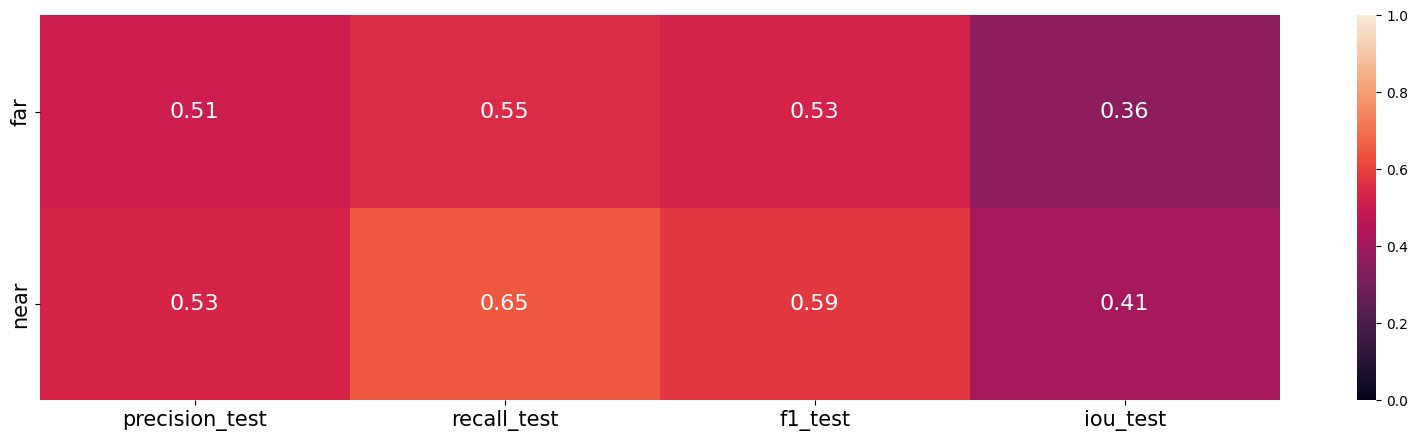

In [5]:
def runs_to_df(runs, metrics=["precision", "recall", "f1", "iou"],
                                splits=["train", "test", "valid"], pref="UTAE_hedge_1.1_"):
    run_metrics = {r:load_metrics(os.path.join(model_dir, r)) for r in runs}

    data={
            f"{m}_{s}": [run_metrics[r][f"{m}_{s}"][0]  for r in runs] for (s,m) in itertools.product(splits,metrics)  
        }

    
    df = pd.DataFrame(
        index=pd.Index([r.removeprefix(pref) for r in runs]),
        data=data
    )

    return df

def visualize_results_as_heatmap(ax: plt.Axes, runs, metrics=["precision", "recall", "f1", "iou"],
                                splits=["train", "test", "valid"], pref="UTAE_hedge_1.1"):
    df = runs_to_df(runs, metrics, splits,)
    
    seaborn.heatmap(df, ax=ax, annot=True, vmax=1, vmin=0,             # Specify format (e.g., integer)
            annot_kws={"fontsize": 16})
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
fig,ax = plt.subplots(figsize=(20,5))
visualize_results_as_heatmap(ax, near_far_runs, splits=["test"])
    

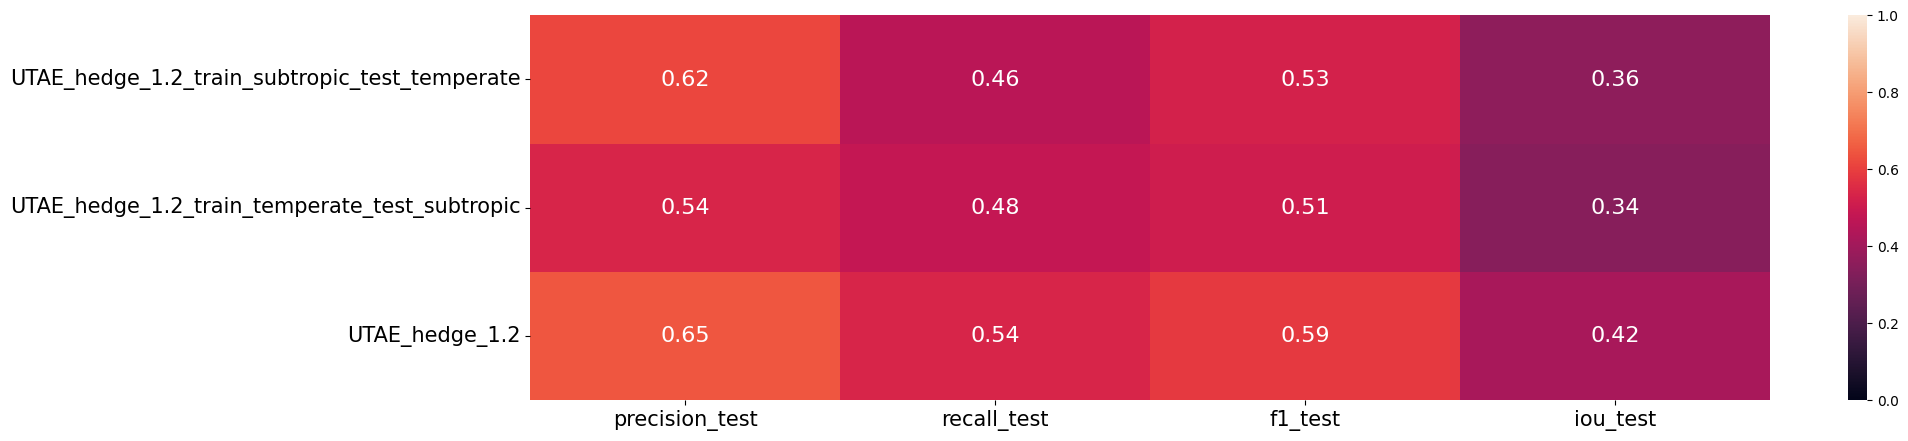

In [6]:
fig,ax = plt.subplots(figsize=(20,5))
visualize_results_as_heatmap(ax, different_thz_class_runs, splits=["test"])

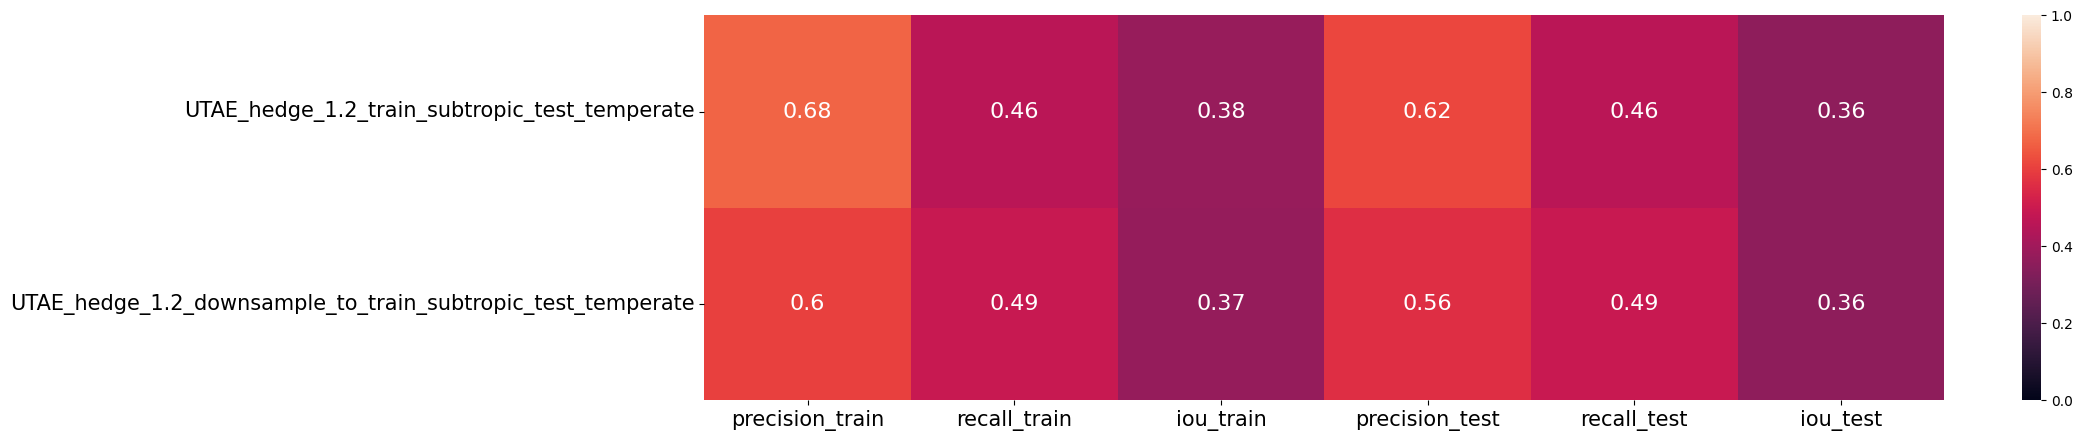

In [7]:
fig,ax = plt.subplots(figsize=(20,5))
visualize_results_as_heatmap(ax, verify_train_sub_test_temp_runs, metrics=["precision", "recall", "iou"], splits=["train","test"])

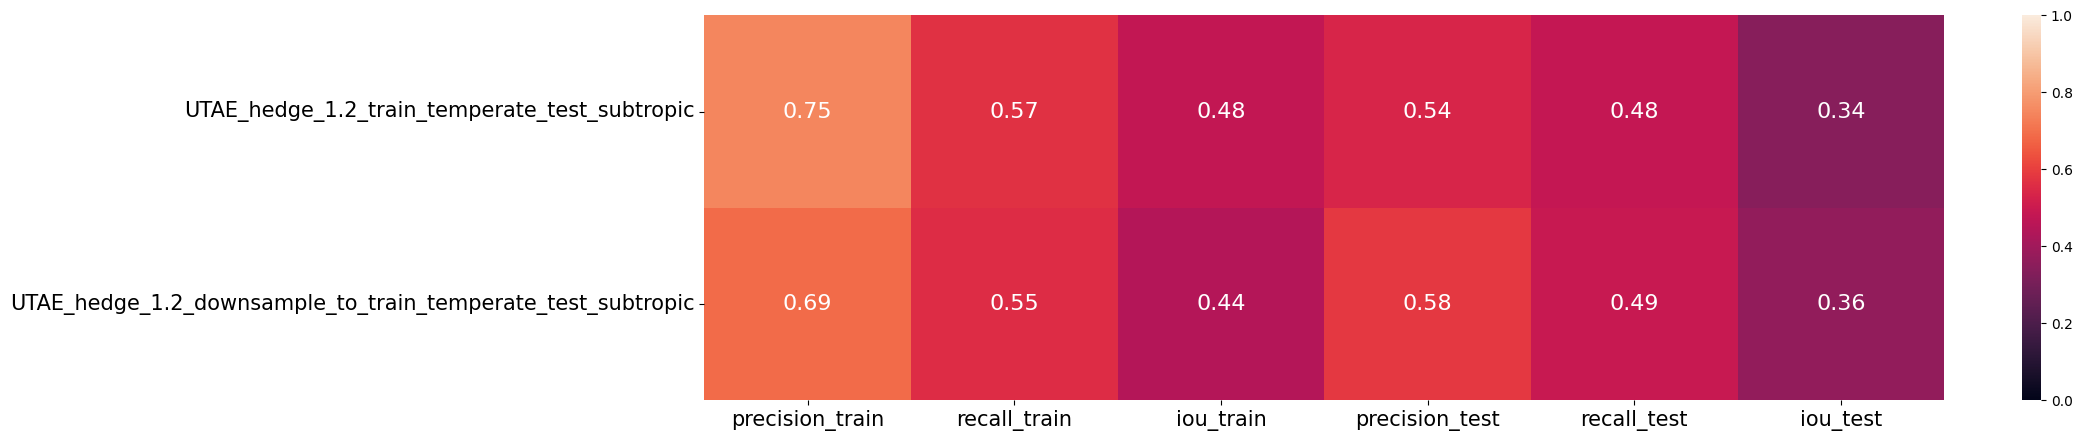

In [8]:
fig,ax = plt.subplots(figsize=(20,5))
visualize_results_as_heatmap(ax, verify_train_temp_test_sub_runs, metrics=["precision", "recall", "iou"], splits=["train","test"])